In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os



# Load dataset

In [2]:
df = pd.read_csv("final_merged_dataset.csv", low_memory=False)

df.columns = df.columns.str.strip()

df = df.replace(
    ["*", "-", "", "NULL", "null", "NaN", "nan"],
    np.nan
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (92137, 171)
                OrgType  OrgCode  OrgName VariableType    VariableA VariableB  \
0  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     18 to 25       NaN   
1  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     26 to 64       NaN   
2  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     65 to 74       NaN   
3  Commissioning Region  UNKNOWN  UNKNOWN    Age Group     75 to 89       NaN   
4  Commissioning Region  UNKNOWN  UNKNOWN    Age Group  90 and over       NaN   

  Count_ReferralsReceived Count_AccessingServices Count_SecondTreatment  \
0                     435                     185                   115   
1                    1400                     770                   510   
2                      40                      25                    15   
3                      20                      10                     5   
4                     NaN                     NaN                   NaN   

  Count_FinishedCourseTreatment  .

# Create output folder

In [3]:
output_folder = "dropoff_dna_outputs"
os.makedirs(output_folder, exist_ok=True)

# Find DNA / appointment / session columns

In [4]:
keywords = [
    "dna",
    "didnot",
    "did_not",
    "attend",
    "appointment",
    "session",
    "accessing",
    "finished",
    "treatment"
]

relevant_cols = [
    col for col in df.columns
    if any(key.lower() in col.lower() for key in keywords)
]

print("Relevant columns:")
for col in relevant_cols:
    print(col)

Relevant columns:
Count_AccessingServices
Count_SecondTreatment
Count_FinishedCourseTreatment
Count_EndedBeforeTreatment
Count_EndedAfterOneTreatment
Mean_ApptsFinishedCourseTreatment
Mean_WaitAccessingServices
Mean_WaitFinishedCourseTreatment
Count_FinishedTreatmentFirst6Months
Count_FinishedTreatmentFirst6MonthsFollowUp
Percentage_FollowUpAppointment
Count_ApptsFinishedCourseTreatment
Count_FinishedCourseTreatmentContactDuration
Mean_TreatmentAppointmentsRecovery
Mean_TreatmentAppointmentsImprovement
Mean_TreatmentAppointmentsNoChange
Mean_TreatmentAppointmentsDeterioration
Mean_TreatmentAppointmentsReliableRecovery
Count_FinishedCourseTreatment_with_EmpSup
Count_FinishedCourseTreatment_employment
Count_EmploymentStatusEndTreatment_Employed
CountEmploymentStatusEndTreatment_UnemployedAndSeekingWork
CountEmploymentStatusEndTreatment_Students
CountEmploymentStatusEndTreatment_LongTermSick
CountEmploymentStatusEndTreatment_Homemaker
CountEmploymentStatusEndTreatment_NotReceivingBenefits

# KEEP VALID REGIONS

In [5]:
df = df[
    (df["OrgName"] != "UNKNOWN") &
    (df["OrgName"] != "All")
]

df = df[
    df["OrgName"].str.contains(
        "COMMISSIONING REGION",
        case=False,
        na=False
    )
]

print(df["OrgName"].value_counts())

OrgName
LONDON COMMISSIONING REGION                      463
SOUTH WEST COMMISSIONING REGION                  463
SOUTH EAST COMMISSIONING REGION                  463
MIDLANDS COMMISSIONING REGION                    463
EAST OF ENGLAND COMMISSIONING REGION             463
NORTH WEST COMMISSIONING REGION                  463
NORTH EAST AND YORKSHIRE COMMISSIONING REGION    463
Name: count, dtype: int64


# CONVERT IMPORTANT COLUMNS

In [6]:
important_cols = [
    "Count_AccessingServices",
    "Count_FinishedCourseTreatment",
    "Count_FinishedTreatmentFirst6MonthsFollowUp"
]

for col in important_cols:
    
    if col in df.columns:
        
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

print(df[important_cols].describe())

       Count_AccessingServices  Count_FinishedCourseTreatment  \
count              1915.000000                    1903.000000   
mean              15433.417755                    9761.213873   
std               33461.817586                   20000.033645   
min                   5.000000                       5.000000   
25%                 265.000000                     212.500000   
50%                1785.000000                    1220.000000   
75%               10160.000000                    7097.500000   
max              209500.000000                  131280.000000   

       Count_FinishedTreatmentFirst6MonthsFollowUp  
count                                     7.000000  
mean                                    753.571429  
std                                     882.414841  
min                                      20.000000  
25%                                     170.000000  
50%                                     420.000000  
75%                                    1132

# DROP-OFF ANALYSIS

In [7]:
dropoff_summary = df.groupby(
    "OrgName",
    as_index=False
).agg(
    Total_Accessing_Services=(
        "Count_AccessingServices",
        "sum"
    ),
    
    Total_Finished_Treatment=(
        "Count_FinishedCourseTreatment",
        "sum"
    )
)

dropoff_summary["Dropoff_Count"] = (
    dropoff_summary["Total_Accessing_Services"] -
    dropoff_summary["Total_Finished_Treatment"]
)

dropoff_summary["Dropoff_Rate"] = (
    dropoff_summary["Dropoff_Count"] /
    dropoff_summary["Total_Accessing_Services"]
) * 100

dropoff_summary = dropoff_summary.sort_values(
    "Dropoff_Rate",
    ascending=False
)

print(dropoff_summary)

                                         OrgName  Total_Accessing_Services  \
4                NORTH WEST COMMISSIONING REGION                 4241310.0   
3  NORTH EAST AND YORKSHIRE COMMISSIONING REGION                 4663965.0   
1                    LONDON COMMISSIONING REGION                 5065950.0   
0           EAST OF ENGLAND COMMISSIONING REGION                 3773970.0   
6                SOUTH WEST COMMISSIONING REGION                 2475530.0   
5                SOUTH EAST COMMISSIONING REGION                 4199240.0   
2                  MIDLANDS COMMISSIONING REGION                 5135030.0   

   Total_Finished_Treatment  Dropoff_Count  Dropoff_Rate  
4                 2263070.0      1978240.0     46.642193  
3                 2771295.0      1892670.0     40.580708  
1                 3110980.0      1954970.0     38.590393  
0                 2321750.0      1452220.0     38.479903  
6                 1635560.0       839970.0     33.930916  
5                 284

# SAVE CSV

In [8]:
dropoff_summary.to_csv(
    "dropoff_rate_by_region.csv",
    index=False
)

print("CSV saved")

CSV saved


#  Keep only valid region rows

In [9]:
df = df[
    (df["OrgName"] != "UNKNOWN") &
    (df["OrgName"] != "All")
].copy()

# Commissioning region level
region_df = df[
    df["OrgName"].str.contains(
        "COMMISSIONING REGION",
        case=False,
        na=False
    )
].copy()

print("Region dataset shape:", region_df.shape)
print(region_df["OrgName"].value_counts())

Region dataset shape: (3241, 171)
OrgName
LONDON COMMISSIONING REGION                      463
SOUTH WEST COMMISSIONING REGION                  463
SOUTH EAST COMMISSIONING REGION                  463
MIDLANDS COMMISSIONING REGION                    463
EAST OF ENGLAND COMMISSIONING REGION             463
NORTH WEST COMMISSIONING REGION                  463
NORTH EAST AND YORKSHIRE COMMISSIONING REGION    463
Name: count, dtype: int64


# Convert important numeric columns

In [10]:
possible_numeric_cols = [
    "Count_AccessingServices",
    "Count_FinishedCourseTreatment",
    "Count_Attended",
    "Count_DidNotAttend",
    "Count_Appointment",
    "Count_Appointments",
    "Count_FirstTreatment",
    "Count_SecondTreatment",
    "Count_FinishedTreatmentFirst6MonthsFollowUp",
    "Percentage_FollowUpAppointment"
]

for col in possible_numeric_cols:
    if col in region_df.columns:
        region_df[col] = (
            region_df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
        )
        region_df[col] = pd.to_numeric(region_df[col], errors="coerce")

# Check available key columns

In [11]:
for col in possible_numeric_cols:
    if col in region_df.columns:
        print(col, "available")
    else:
        print(col, "not found")

Count_AccessingServices available
Count_FinishedCourseTreatment available
Count_Attended not found
Count_DidNotAttend not found
Count_Appointment not found
Count_Appointments not found
Count_FirstTreatment not found
Count_SecondTreatment available
Count_FinishedTreatmentFirst6MonthsFollowUp available
Percentage_FollowUpAppointment available


# DROP-OFF CHART

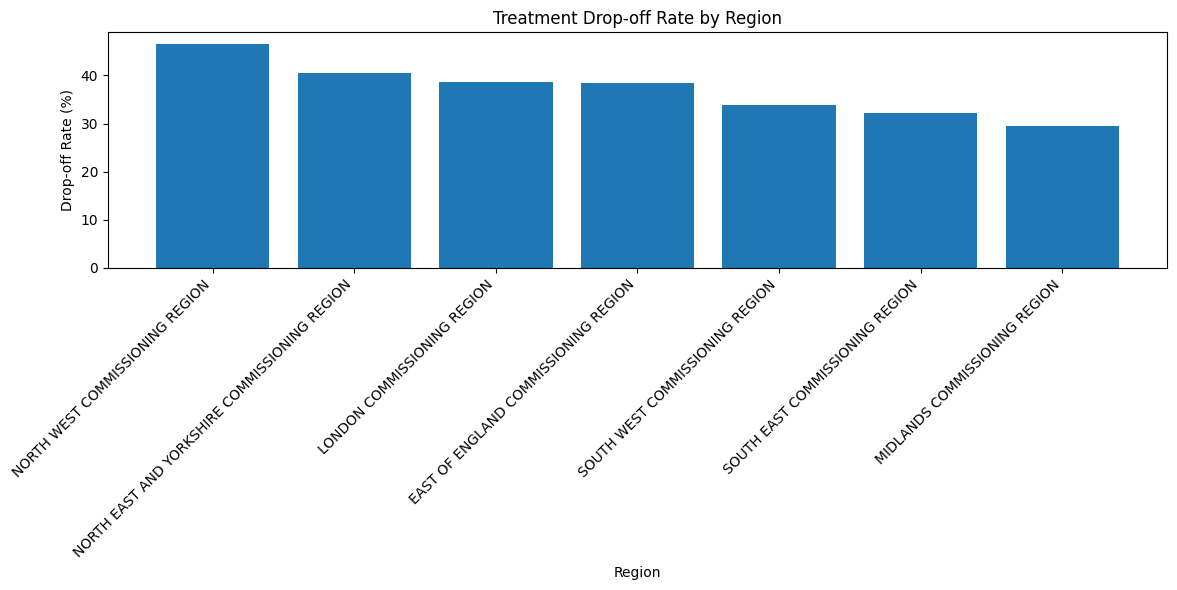

In [12]:
plt.figure(figsize=(12,6))

plt.bar(
    dropoff_summary["OrgName"],
    dropoff_summary["Dropoff_Rate"]
)

plt.title(
    "Treatment Drop-off Rate by Region"
)

plt.xlabel("Region")

plt.ylabel("Drop-off Rate (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "dropoff_rate_chart.png",
    dpi=300
)

plt.show()

# TREATMENT FUNNEL

In [13]:
funnel_steps = [
    (
        "Accessing Services",
        df["Count_AccessingServices"].sum()
    ),
    
    (
        "Finished Treatment",
        df["Count_FinishedCourseTreatment"].sum()
    ),
    
    (
        "6-Month Follow-up",
        df["Count_FinishedTreatmentFirst6MonthsFollowUp"].sum()
    )
]

funnel_df = pd.DataFrame(
    funnel_steps,
    columns=["Stage", "Count"]
)

print(funnel_df)

                Stage       Count
0  Accessing Services  29554995.0
1  Finished Treatment  18575590.0
2   6-Month Follow-up      5275.0


# FUNNEL DROPOFF

In [14]:
funnel_df["Previous_Count"] = (
    funnel_df["Count"].shift(1)
)

funnel_df["Stage_Dropoff"] = (
    funnel_df["Previous_Count"] -
    funnel_df["Count"]
)

funnel_df["Stage_Dropoff_Rate"] = (
    funnel_df["Stage_Dropoff"] /
    funnel_df["Previous_Count"]
) * 100

print(funnel_df)

                Stage       Count  Previous_Count  Stage_Dropoff  \
0  Accessing Services  29554995.0             NaN            NaN   
1  Finished Treatment  18575590.0      29554995.0     10979405.0   
2   6-Month Follow-up      5275.0      18575590.0     18570315.0   

   Stage_Dropoff_Rate  
0                 NaN  
1           37.149067  
2           99.971603  


# SAVE FUNNEL CSV

In [15]:
funnel_df.to_csv(
    "treatment_funnel_summary.csv",
    index=False
)

print("Funnel CSV saved")

Funnel CSV saved


# FUNNEL CHART

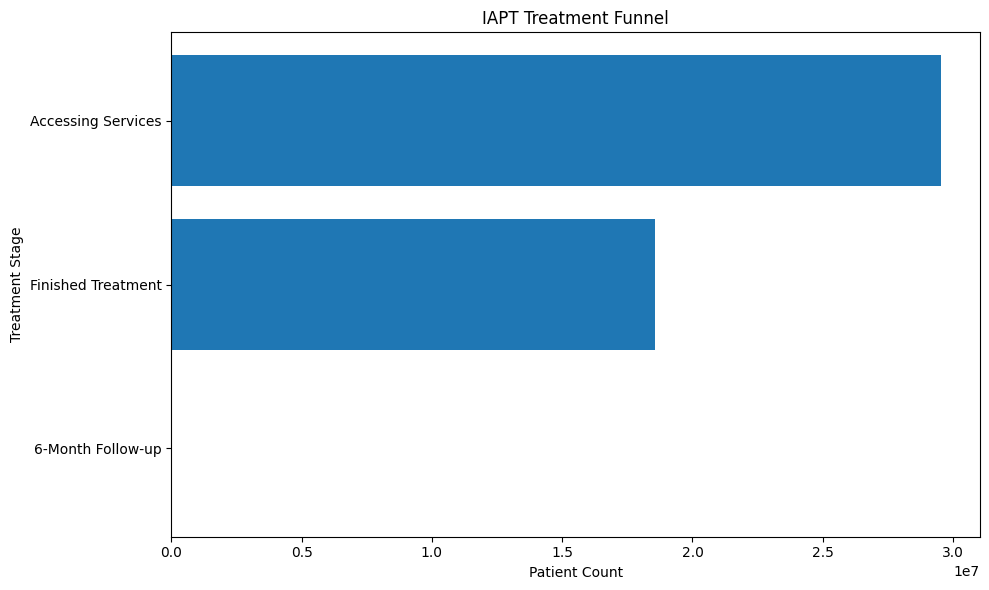

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    funnel_df["Stage"],
    funnel_df["Count"]
)

plt.title(
    "IAPT Treatment Funnel"
)

plt.xlabel("Patient Count")

plt.ylabel("Treatment Stage")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "treatment_funnel_chart.png",
    dpi=300
)

plt.show()

# FOLLOW-UP RETENTION

In [17]:
retention_rate = (
    df["Count_FinishedTreatmentFirst6MonthsFollowUp"].sum()
    /
    df["Count_FinishedCourseTreatment"].sum()
) * 100

print(
    "6-Month Follow-up Retention Rate:",
    round(retention_rate, 2),
    "%"
)

6-Month Follow-up Retention Rate: 0.03 %


# CREATE DNA SUMMARY

In [18]:
dna_summary = df.groupby(
    "OrgName",
    as_index=False
).agg(
    Total_Accessing_Services=(
        "Count_AccessingServices",
        "sum"
    ),

    Total_Finished_Treatment=(
        "Count_FinishedCourseTreatment",
        "sum"
    )
)

# DNA CALCULATION

In [19]:
dna_summary["Estimated_DNA_Count"] = (
    dna_summary["Total_Accessing_Services"] -
    dna_summary["Total_Finished_Treatment"]
)

dna_summary["Estimated_DNA_Rate"] = (
    dna_summary["Estimated_DNA_Count"] /
    dna_summary["Total_Accessing_Services"]
) * 100

# CLEAN RESULTS

In [20]:
dna_summary = dna_summary.replace(
    [np.inf, -np.inf],
    np.nan
)

dna_summary = dna_summary.dropna()

dna_summary = dna_summary.sort_values(
    "Estimated_DNA_Rate",
    ascending=False
)

print(dna_summary)

                                         OrgName  Total_Accessing_Services  \
4                NORTH WEST COMMISSIONING REGION                 4241310.0   
3  NORTH EAST AND YORKSHIRE COMMISSIONING REGION                 4663965.0   
1                    LONDON COMMISSIONING REGION                 5065950.0   
0           EAST OF ENGLAND COMMISSIONING REGION                 3773970.0   
6                SOUTH WEST COMMISSIONING REGION                 2475530.0   
5                SOUTH EAST COMMISSIONING REGION                 4199240.0   
2                  MIDLANDS COMMISSIONING REGION                 5135030.0   

   Total_Finished_Treatment  Estimated_DNA_Count  Estimated_DNA_Rate  
4                 2263070.0            1978240.0           46.642193  
3                 2771295.0            1892670.0           40.580708  
1                 3110980.0            1954970.0           38.590393  
0                 2321750.0            1452220.0           38.479903  
6                 16

In [21]:
dna_summary.to_csv(
    "estimated_dna_rate_by_region.csv",
    index=False
)

print("CSV saved")

CSV saved


# PLOT DNA RATE CHART

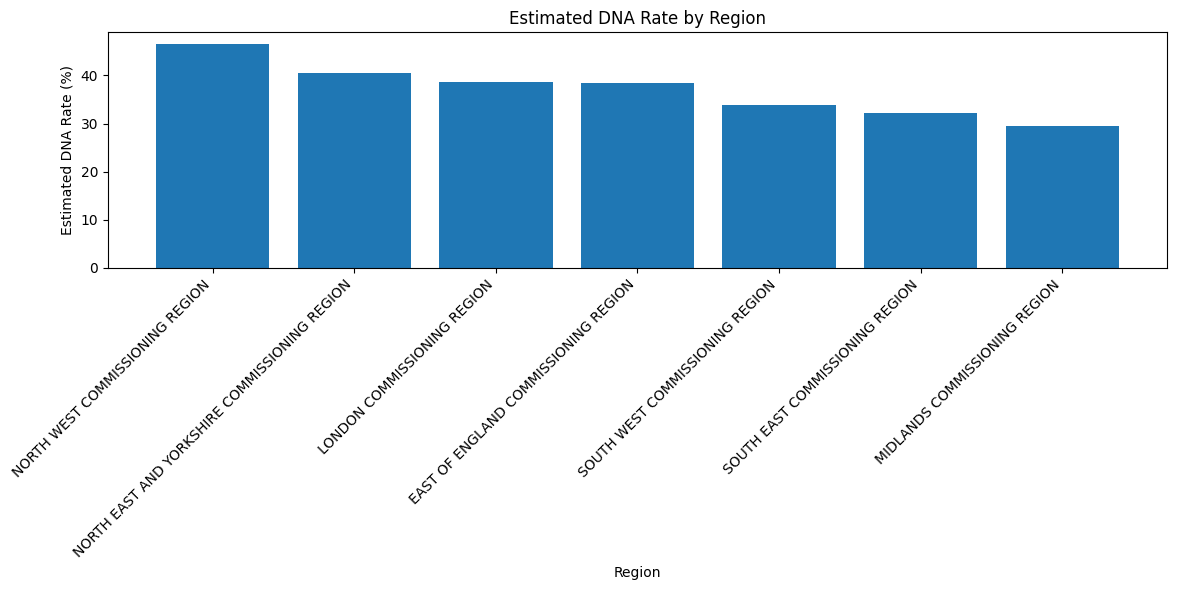

In [22]:
plt.figure(figsize=(12,6))

plt.bar(
    dna_summary["OrgName"],
    dna_summary["Estimated_DNA_Rate"]
)

plt.title(
    "Estimated DNA Rate by Region"
)

plt.xlabel("Region")

plt.ylabel("Estimated DNA Rate (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "estimated_dna_rate_chart.png",
    dpi=300
)

plt.show()

# NATIONAL DNA RATE

In [23]:
national_dna_rate = (
    dna_summary["Estimated_DNA_Count"].sum()
    /
    dna_summary["Total_Accessing_Services"].sum()
) * 100

print(
    "National Estimated DNA Rate:",
    round(national_dna_rate, 2),
    "%"
)

National Estimated DNA Rate: 37.15 %


# SESSION-WISE ESTIMATED DNA

In [24]:
session_cols = [
    col for col in df.columns
    if "Session" in col
]

print(session_cols)

['Count_InternetEnabledTherapySessions']


# FUNNEL CHART

In [25]:
funnel_steps = [
    (
        "Accessing Services",
        df["Count_AccessingServices"].sum()
    ),

    (
        "Finished Treatment",
        df["Count_FinishedCourseTreatment"].sum()
    )
]

funnel_df = pd.DataFrame(
    funnel_steps,
    columns=["Stage", "Count"]
)

print(funnel_df)

                Stage       Count
0  Accessing Services  29554995.0
1  Finished Treatment  18575590.0


# FUNNEL PLOT

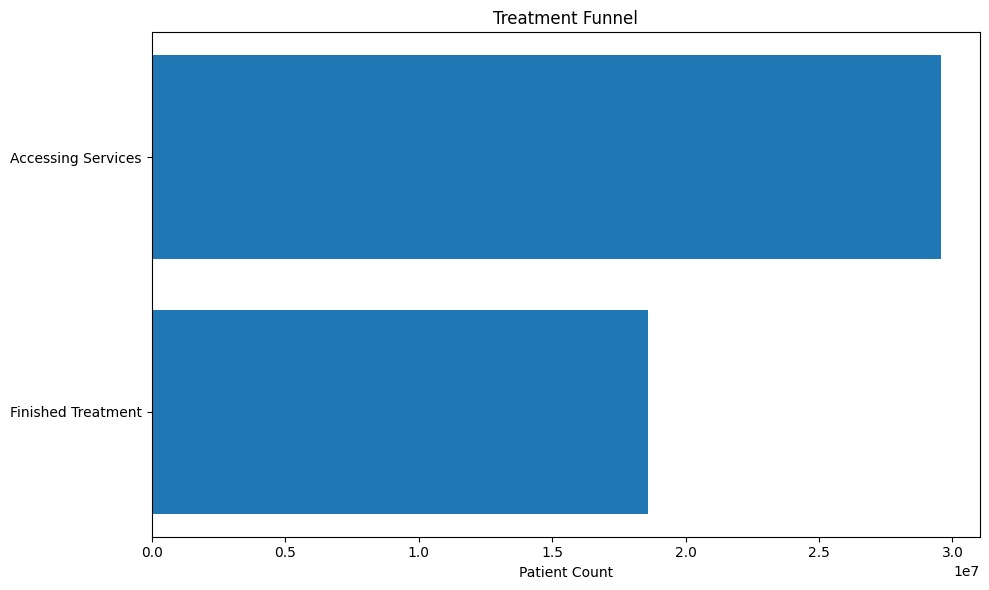

In [26]:
plt.figure(figsize=(10,6))

plt.barh(
    funnel_df["Stage"],
    funnel_df["Count"]
)

plt.title(
    "Treatment Funnel"
)

plt.xlabel("Patient Count")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "treatment_funnel_chart.png",
    dpi=300
)

plt.show()